# Explore here

In [ ]:
# Paises seleccionado son:
# ESP ESPAÑA 
# MEX MÉXICO
# BRA BRASIL
# KOR COREA 
# NGA NIGERIA 

# Indicadores Seleccionados:
# P.POP.TOTL: Poblacion total
# NY.GDP.PCAP.CD: PIB per capita (USD actuales)
# EN.ATM.CO2E.PC: Emisiones de CO2 per capita (toneladas metricas)
# SP.DYN.LE00.IN: Esperanza de vida al nacer (años)

In [24]:
# Paso 1: Preparar entorno
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text


In [4]:
#Paso 2: Explorar la API
url = "https://api.worldbank.org/v2/country/ESP/indicator/NY.GDP.PCAP.CD"

# Parámetros que le pasamos a la API

params = {"format": "json", "per_page": 5, "date": "2010:2024"}

respuesta = requests.get(url, params= params)

if respuesta.status_code == 200:
    datos = respuesta.json()
    print("Metadatos:", datos[0])
    print("Primer registro:", datos[1][0])
else:
    print("Error en la API:", respuesta.status_code)




Metadatos: {'page': 1, 'pages': 3, 'per_page': 5, 'total': 15, 'sourceid': '2', 'lastupdated': '2026-02-24'}
Primer registro: {'indicator': {'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per capita (current US$)'}, 'country': {'id': 'ES', 'value': 'Spain'}, 'countryiso3code': 'ESP', 'date': '2024', 'value': 35326.7683069278, 'unit': '', 'obs_status': '', 'decimal': 1}


In [5]:
#Paso 3: Descargamos el PIB per capital de Espña

respuesta_esp = requests.get(
    "https://api.worldbank.org/v2/country/ESP/indicator/NY.GDP.PCAP.CD", 
    params={"format": "json", "date": "2010:2024", "per_page": 100})

pib_esp = respuesta_esp.json()[1] 
print("España: registros descargados:", len(pib_esp))

España: registros descargados: 15


In [6]:
#Paso 3: Descargamos el PIB per capital de México

respuesta_mex = requests.get("https://api.worldbank.org/v2/country/MEX/indicator/NY.GDP.PCAP.CD",
                             params={"format": "json", "date": "2010:2024", "per_page": 100})

pib_mex = respuesta_mex.json()[1]
print("México: registros descargados:", len(pib_mex))

México: registros descargados: 15


In [7]:
#Paso 3: Descargamos el PIB per capital de Brasil

respuesta_bra = requests.get("https://api.worldbank.org/v2/country/BRA/indicator/NY.GDP.PCAP.CD",
    params={"format": "json", "date": "2010:2024", "per_page": 100})

pib_bra = respuesta_bra.json()[1]
print("Brasil: registros descargados:", len(pib_bra))


Brasil: registros descargados: 15


In [8]:
#Paso 3: Descargamos el PIB per capital de Corea del Sur

respuesta_kor = requests.get("https://api.worldbank.org/v2/country/KOR/indicator/NY.GDP.PCAP.CD",
    params={"format": "json", "date": "2010:2024", "per_page": 100})

pib_kor = respuesta_kor.json()[1]
print("Corea del Sur: registros descargados:", len(pib_kor))



Corea del Sur: registros descargados: 15


In [9]:
#Paso 3: Descargamos el PIB per capital de Nigeria

respuesta_nga = requests.get("https://api.worldbank.org/v2/country/NGA/indicator/NY.GDP.PCAP.CD",
    params={"format": "json", "date": "2010:2024", "per_page": 100})

pib_nga = respuesta_nga.json()[1]
print("Nigeria: registros descargados:", len(pib_nga))

Nigeria: registros descargados: 15


In [10]:
#Juntamos todos los datos en una sola lista

todos_pib = pib_esp + pib_mex + pib_bra + pib_kor + pib_nga
print("Total de registros:", len(todos_pib))

Total de registros: 75


In [12]:
# Hacemos lo mismo para la esperanza de vida 
def pedir_api(url, params):
    respuesta = requests.get(url, params=params)
    if respuesta.status_code == 200:
        return respuesta.json()
    else:
        print("Error:", respuesta.status_code)
        return None

params_vida = {"format": "json", "date": "2010:2024", "per_page": 100}
vida_esp = pedir_api("https://api.worldbank.org/v2/country/ESP/indicator/SP.DYN.LE00.IN", params_vida)[1]
vida_mex = pedir_api("https://api.worldbank.org/v2/country/MEX/indicator/SP.DYN.LE00.IN", params_vida)[1]
vida_bra = pedir_api("https://api.worldbank.org/v2/country/BRA/indicator/SP.DYN.LE00.IN", params_vida)[1]
vida_kor = pedir_api("https://api.worldbank.org/v2/country/KOR/indicator/SP.DYN.LE00.IN", params_vida)[1]
vida_nga = pedir_api("https://api.worldbank.org/v2/country/NGA/indicator/SP.DYN.LE00.IN", params_vida)[1]

todos_vida = vida_esp + vida_mex + vida_bra + vida_kor + vida_nga
print("Total registros:", len(todos_vida))



Total registros: 75


In [13]:
#Paso 4: Transformar respuesta a DataFrames
#Creo una lista para guardarlas filas que me interesan

filas_pib = []

for registro in todos_pib:
    fila = {"country": registro["countryiso3code"], "year":    registro["date"], "value":   registro["value"]}

    filas_pib.append(fila)

#La lista que he creado ahora la convierto en un DataFrame

df_pib = pd.DataFrame(filas_pib)

#El año viene como texto asi que lo convertimos a numero

df_pib["year"] = df_pib["year"].astype(int)

#Value lo convertimos a número

df_pib["value"] = pd.to_numeric(df_pib["value"], errors="coerce")

#Eliminamos valores nulos

df_pib = df_pib.dropna(subset=["value"])

print(df_pib.head(10))






  country  year         value
0     ESP  2024  35326.768307
1     ESP  2023  33493.222541
2     ESP  2022  30319.498720
3     ESP  2021  30799.477594
4     ESP  2020  27233.942646
5     ESP  2019  29786.524569
6     ESP  2018  30602.421288
7     ESP  2017  28381.342560
8     ESP  2016  26755.606115
9     ESP  2015  25982.441620


In [14]:
#Paso 4: Transformar respuesta a DataFrames
# Ahora para la esperanza de vida

filas_vida = []

for registro in todos_vida:
    fila = {"country": registro["countryiso3code"], "year":    registro["date"], "value":   registro["value"]}

    filas_vida.append(fila)

df_vida = pd.DataFrame(filas_vida)
df_vida["year"]  = df_vida["year"].astype(int)
df_vida["value"] = pd.to_numeric(df_vida["value"], errors="coerce")
df_vida = df_vida.dropna(subset=["value"])

print(df_vida.head(10))







   country  year      value
1      ESP  2023  83.882927
2      ESP  2022  83.134146
3      ESP  2021  83.178049
4      ESP  2020  82.231707
5      ESP  2019  83.831707
6      ESP  2018  83.431707
7      ESP  2017  83.282927
8      ESP  2016  83.329268
9      ESP  2015  82.831707
10     ESP  2014  83.229268


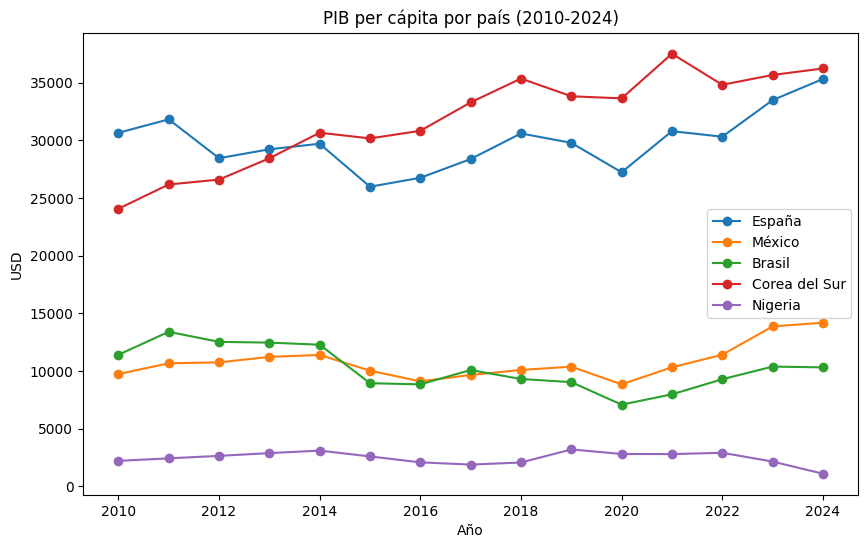

In [15]:
#Paso 5: Analisis y visualizaciones
#Gráfico 1 Lineal: Evolución del PIB per Capital 
# Voy a sacar la línea de cada pais 

plt.figure(figsize=(10, 6))

esp = df_pib[df_pib["country"] == "ESP"]
plt.plot(esp["year"], esp["value"], marker="o", label="España")

mex = df_pib[df_pib["country"] == "MEX"]
plt.plot(mex["year"], mex["value"], marker="o", label="México")

bra = df_pib[df_pib["country"] == "BRA"]
plt.plot(bra["year"], bra["value"], marker="o", label="Brasil")

kor = df_pib[df_pib["country"] == "KOR"]
plt.plot(kor["year"], kor["value"], marker="o", label="Corea del Sur")

nga = df_pib[df_pib["country"] == "NGA"]
plt.plot(nga["year"], nga["value"], marker="o", label="Nigeria")

plt.title("PIB per cápita por país (2010-2024)")
plt.xlabel("Año")
plt.ylabel("USD")
plt.legend()
plt.show()


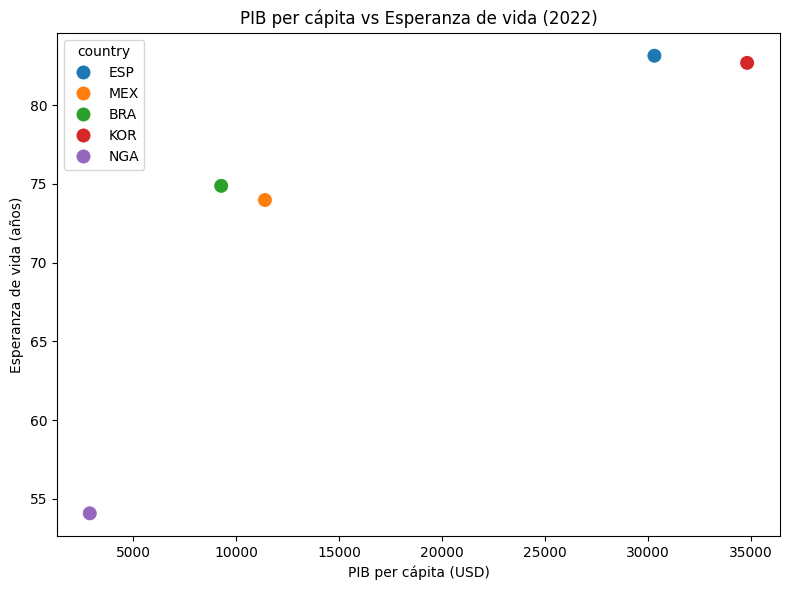

In [35]:
#Grafico 2: Pib vs Esperanza de vida 
#analizo solo el último año ya que podemos visualizarlo mejor siendo solo un año ya que si son todos los años
#es un caos de puntos

ultimo_año = 2022

pib_latest = df_pib.query("year == @ultimo_año").rename(columns={"value": "pib_per_capita"})
vida_latest = df_vida.query("year == @ultimo_año").rename(columns={"value": "esperanza_vida"})

merged = pd.merge(
    pib_latest[["country", "pib_per_capita"]],
    vida_latest[["country", "esperanza_vida"]],
    on="country",
    how="inner",
)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=merged, x="pib_per_capita", y="esperanza_vida", hue="country", s=120)
plt.title(f"PIB per cápita vs Esperanza de vida ({ultimo_año})")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Esperanza de vida (años)")
plt.tight_layout()
plt.show()


In [ ]:
#Paso 6: Guardar en la Base de Dato 
import sqlite3
conexion = sqlite3.connect("world_bank_analysis.db")

#Guardo

df_pib.to_sql("indicator_gdp_per_capita", con=conexion, if_exists="replace", index=False)
df_vida.to_sql("indicator_life_expectancy", con=conexion, if_exists="replace", index=False)

#Compruebo
print(pd.read_sql("SELECT * FROM indicator_gdp_per_capita LIMIT 5", con=conexion))
print(pd.read_sql("SELECT * FROM indicator_life_expectancy LIMIT 5", con=conexion))

conexion.close()
print("Todo correcto")




  country  year         value
0     ESP  2024  35326.768307
1     ESP  2023  33493.222541
2     ESP  2022  30319.498720
3     ESP  2021  30799.477594
4     ESP  2020  27233.942646
  country  year      value
0     ESP  2023  83.882927
1     ESP  2022  83.134146
2     ESP  2021  83.178049
3     ESP  2020  82.231707
4     ESP  2019  83.831707
Todo correcto
